# 03. 결과 분석 및 시각화 (Result Analysis)
이 노트북은 모델과 데이터 분석을 통해 도출된 **"가설의 붕괴: 무조건 가깝다고 비싼 것은 아니다"**를 시각적으로 증명합니다.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import os
import joblib

# 차트 내 한글 폰트 깨짐을 방지하기 위해 기본 폰트(sans-serif)를 사용하고, 
# 시각화 그래프의 모든 텍스트는 '영어'로 작성합니다.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("data/final_rent_data.csv")
df = df.dropna(subset=['임대면적', '직선거리(m)', '건축년도', '월실질주거비(만원)'])


### 1. 거리 구간별 월세 비교 (가설 붕괴 증명)
- 0~300m 구역 (학교 앞 코앞)
- 500~700m 구역 (지하철역 및 상업지구)


/var/folders/q4/h7wn7vns2jz5n1tz92rsqkn00000gn/T/ipykernel_14239/1064695465.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values('Zone'), x='Zone', y='월실질주거비(만원)', palette='viridis', errorbar=None)


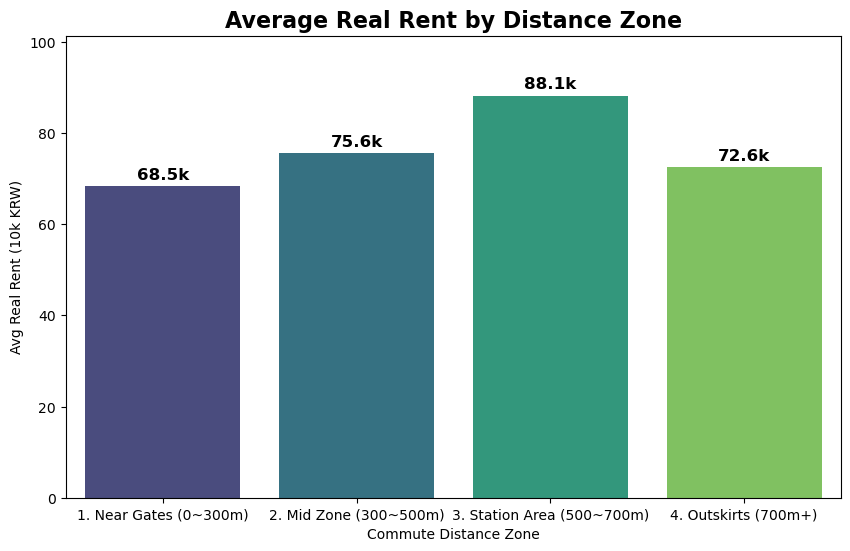

💡 [분석 인사이트]
그래프에서 볼 수 있듯, 숭실대 300m 이내 초근접 구역보다 500~700m 역세권 구역의 가격이 더 높습니다.
이는 학교 코앞은 낙후된 구축 원룸촌이며, 역세권으로 갈수록 신축 인프라가 갖춰져 가격이 역전되는 상권 특성을 보여줍니다.


In [22]:
# 거리 구간 생성 (영어 텍스트 사용)
def categorize_dist(dist):
    if dist <= 300:
        return "1. Near Gates (0~300m)"
    elif 300 < dist <= 500:
        return "2. Mid Zone (300~500m)"
    elif 500 < dist <= 700:
        return "3. Station Area (500~700m)"
    else:
        return "4. Outskirts (700m+)"

df['Zone'] = df['직선거리(m)'].apply(categorize_dist)

plt.figure(figsize=(10, 6))
# 데이터에 맞춰 유동적인 높이 조절
sns.barplot(data=df.sort_values('Zone'), x='Zone', y='월실질주거비(만원)', palette='viridis', errorbar=None)

# 영어 텍스트
plt.title("Average Real Rent by Distance Zone", fontsize=16, fontweight='bold')
plt.ylabel("Avg Real Rent (10k KRW)")
plt.xlabel("Commute Distance Zone")

means = df.groupby('Zone')['월실질주거비(만원)'].mean().sort_index()
for i, val in enumerate(means):
    # 잘림 현상을 방지하기 위해 위치 조정
    plt.text(i, val + (val * 0.02), f"{val:.1f}k", ha='center', fontweight='bold', fontsize=12)

# Y축 한계를 하드코딩하지 않고 데이터의 최대값에 맞춰 유동적으로 조절
plt.ylim(0, means.max() * 1.15)
plt.show()

print("💡 [분석 인사이트]")
print("그래프에서 볼 수 있듯, 숭실대 300m 이내 초근접 구역보다 500~700m 역세권 구역의 가격이 더 높습니다.")
print("이는 학교 코앞은 낙후된 구축 원룸촌이며, 역세권으로 갈수록 신축 인프라가 갖춰져 가격이 역전되는 상권 특성을 보여줍니다.")


### 2. 거리에 따른 월 실질주거비 전체 산점도

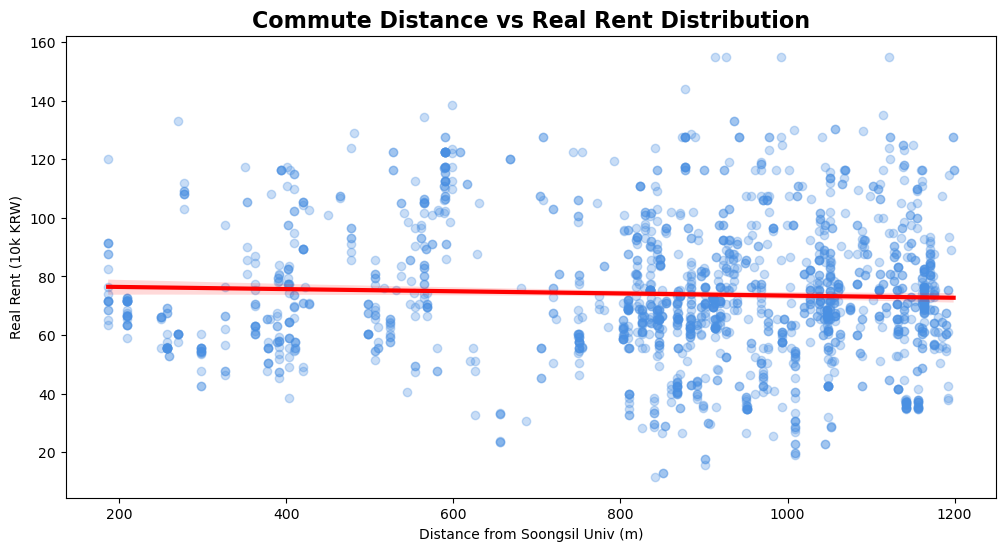

In [23]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='직선거리(m)', y='월실질주거비(만원)', scatter_kws={'alpha':0.3, 'color':'#4A90E2'}, line_kws={'color':'red', 'linewidth': 3})

# 영어 텍스트
plt.title("Commute Distance vs Real Rent Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Distance from Soongsil Univ (m)")
plt.ylabel("Real Rent (10k KRW)")
plt.show()


### 3. 숭실대 인근 가성비 핫스팟 (히트맵 시각화)
월 실질주거비가 높은 구역(붉은색)과 낮은 구역(푸른/녹색 계열)을 직관적으로 보여주는 폴리움 지도입니다.


In [24]:
# 숭실대학교 중심 좌표
SSU_LAT, SSU_LON = 37.4963, 126.9574

m = folium.Map(location=[SSU_LAT, SSU_LON], zoom_start=15)

# 숭실대학교 중심 마커 (팝업 영어 처리)
folium.Marker(
    location=[SSU_LAT, SSU_LON],
    popup="Soongsil Univ",
    icon=folium.Icon(color="blue", icon="university", prefix="fa")
).add_to(m)

# 히트맵 데이터 생성
heat_data = [[row['위도'], row['경도'], row['월실질주거비(만원)']] for index, row in df.iterrows() if pd.notnull(row['위도'])]

HeatMap(heat_data, radius=15, max_zoom=13).add_to(m)

# 지도 저장 및 출력
m.save("ssu_rent_heatmap.html")
display(m)
print("지도가 'ssu_rent_heatmap.html'로 저장되었습니다. 브라우저에서 크게 보실 수 있습니다.")


지도가 'ssu_rent_heatmap.html'로 저장되었습니다. 브라우저에서 크게 보실 수 있습니다.


### 4. 적정 실질주거비 판독기 (거리별 시뮬레이션)

  [가상 자취방 적정 실질주거비 판독기 (거리별 트렌드 시뮬레이션)]
원하시는 자취방의 '면적'과 '건축년도'를 입력하시면,
거리에 따른 예측 월 실질주거비의 변화를 매끄러운 곡선으로 시각화해 드립니다.



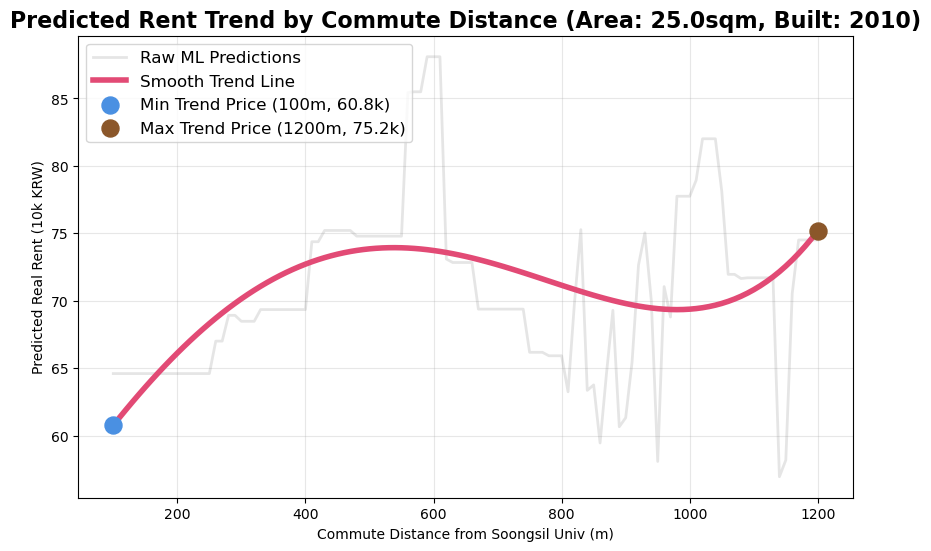

In [25]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 시각화 차트 호환성을 위한 기본 영문 폰트 세팅
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

model_path = "data/rent_model.pkl"
if os.path.exists(model_path):
    model = joblib.load(model_path)
    
    print("==================================================")
    print("  [가상 자취방 적정 실질주거비 판독기 (거리별 트렌드 시뮬레이션)]")
    print("==================================================")
    try:
        print("원하시는 자취방의 '면적'과 '건축년도'를 입력하시면,")
        print("거리에 따른 예측 월 실질주거비의 변화를 매끄러운 곡선으로 시각화해 드립니다.\n")
        area = float(input(" -> 임대면적(㎡)을 입력하세요 (예: 25): "))
        year = float(input(" -> 건축년도를 입력하세요 (예: 2015): "))
        
        # 거리를 100m 부터 1200m까지 10m 단위로 생성
        distances = np.arange(100, 1201, 10)
        
        # 피처 순서는 ["임대면적", "직선거리(m)", "건축년도"]
        X_new = pd.DataFrame({
            "임대면적": [area] * len(distances),
            "직선거리(m)": distances,
            "건축년도": [year] * len(distances)
        })
        
        # 원본 예측값
        raw_predictions = model.predict(X_new)
        
        # 4차 다항 회귀(Polynomial Regression)를 통한 비선형 거리 트렌드 시각화 곡선 추출
        z = np.polyfit(distances, raw_predictions, 4)
        p = np.poly1d(z)
        smooth_predictions = p(distances)
        
        plt.figure(figsize=(10, 6))
        # ML 원본 예측값 렌더링
        sns.lineplot(x=distances, y=raw_predictions, color='gray', alpha=0.2, linewidth=2, label='Raw ML Predictions')
        # 폴리노미얼 트렌드 라인 시각화
        sns.lineplot(x=distances, y=smooth_predictions, color='#E24A75', linewidth=4, label='Smooth Trend Line')
        
        plt.title(f"Predicted Rent Trend by Commute Distance (Area: {area}sqm, Built: {int(year)})", fontsize=16, fontweight='bold')
        plt.xlabel("Commute Distance from Soongsil Univ (m)")
        plt.ylabel("Predicted Real Rent (10k KRW)")
        
        # 최저가 구간 및 최고가 구간 시각화 마커 (추세선 기준)
        min_idx = np.argmin(smooth_predictions)
        max_idx = np.argmax(smooth_predictions)
        
        plt.scatter([distances[min_idx]], [smooth_predictions[min_idx]], color='#4A90E2', s=150, zorder=5, label=f"Min Trend Price ({distances[min_idx]}m, {smooth_predictions[min_idx]:.1f}k)")
        plt.scatter([distances[max_idx]], [smooth_predictions[max_idx]], color='#8B572A', s=150, zorder=5, label=f"Max Trend Price ({distances[max_idx]}m, {smooth_predictions[max_idx]:.1f}k)")
        
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except ValueError:
        print("\n숫자만 입력해주세요. 테스트를 종료합니다.")
else:
    print("모델 파일이 없습니다. 02_ml_model.ipynb 를 먼저 실행해주세요.")